# Wood Species Image Classifier

This project implements a convolutional neural network for classifying wood species from micrograph images.

The model uses transfer learning with a VGG16 convolutional neural network pretrained on ImageNet. The pretrained model is initially frozen while custom classification layers are trained. Selected VGG16 layers are then unfrozen and fine-tuned using the wood micrograph dataset.

The dataset consists of 6,312 expert-curated wood micrograph images covering 20 wood species. The images were provided by DFPPS/CFNR, UPLB.

## 1. Setup

### Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.10.0
NumPy version: 1.23.5
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Configuration

In [2]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123

## 2. Dataset

The dataset is divided into training, validation, and testing subsets. Images are loaded using `image_dataset_from_directory` with categorical labels.

### Dataset Location

In [3]:
DATASET_DIR = "dataset/wood_dataset"

print("Dataset exists:", os.path.exists(DATASET_DIR))

Dataset exists: True


### Train/Validation/Test Split

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    label_mode="categorical",
    validation_split=0.4,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    label_mode="categorical",
    validation_split=0.4,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 6312 files belonging to 20 classes.
Using 3788 files for training.
Found 6312 files belonging to 20 classes.
Using 2524 files for validation.


In [5]:
val_batches = tf.data.experimental.cardinality(val_ds)

test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

### Class Names

In [6]:
class_names = train_ds.class_names

NUM_CLASSES = len(class_names)

print("Class names:", NUM_CLASSES)
print("Number of classes:", len(class_names))

Class names: 20
Number of classes: 20


## 3. Dataset Exploration

Before training the model, we will inspect a sample of images from the dataset to verify that the images and class labels were loaded correctly.

### Sample Images

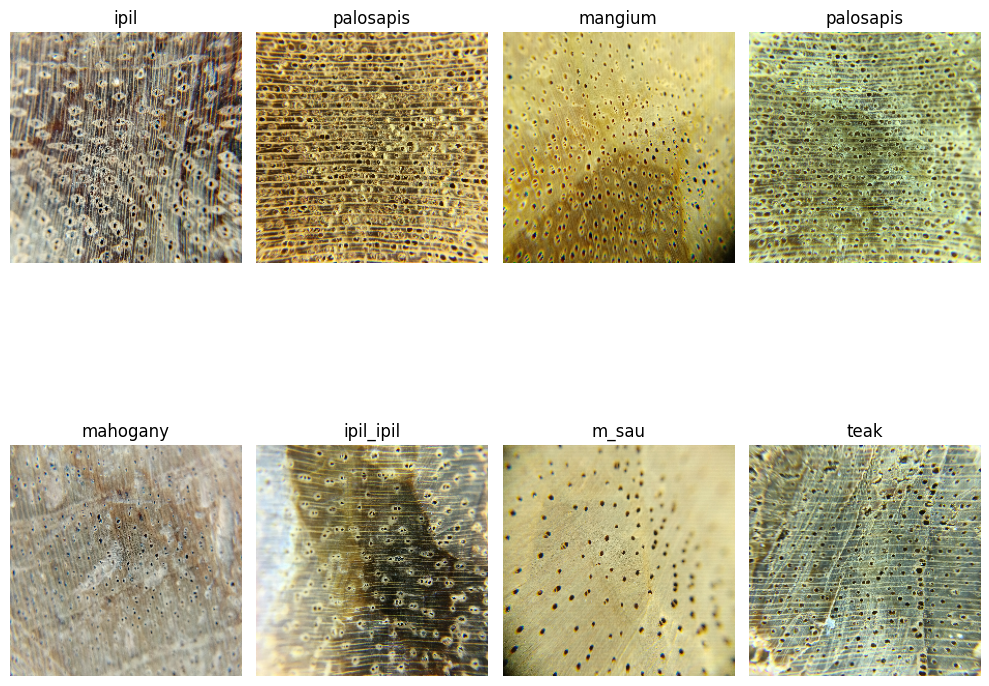

In [7]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(8):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[np.argmax(labels[i].numpy())])
        plt.axis("off")

plt.tight_layout()
plt.show()

### Class Distribution

We will examine how many images are available for each wood species to identify any significant class imbalance.

In [8]:
from collections import Counter

class_counts = Counter()

for _, labels in train_ds:
    class_indices = np.argmax(labels.numpy(), axis=1)
    class_counts.update(class_indices)

for class_index, class_name in enumerate(class_names):
    print(f"{class_name}: {class_counts[class_index]}")

apitong: 191
bagras: 203
bagtikan: 192
gmelina: 200
guijo: 185
ipil: 184
ipil_ipil: 184
kakauate: 184
m_sau: 221
mahogany: 200
mangium: 178
molave: 175
narra: 185
palosapis: 180
raintree: 186
red_lauan: 198
tanguile: 183
teak: 184
white_lauan: 190
yakal: 185


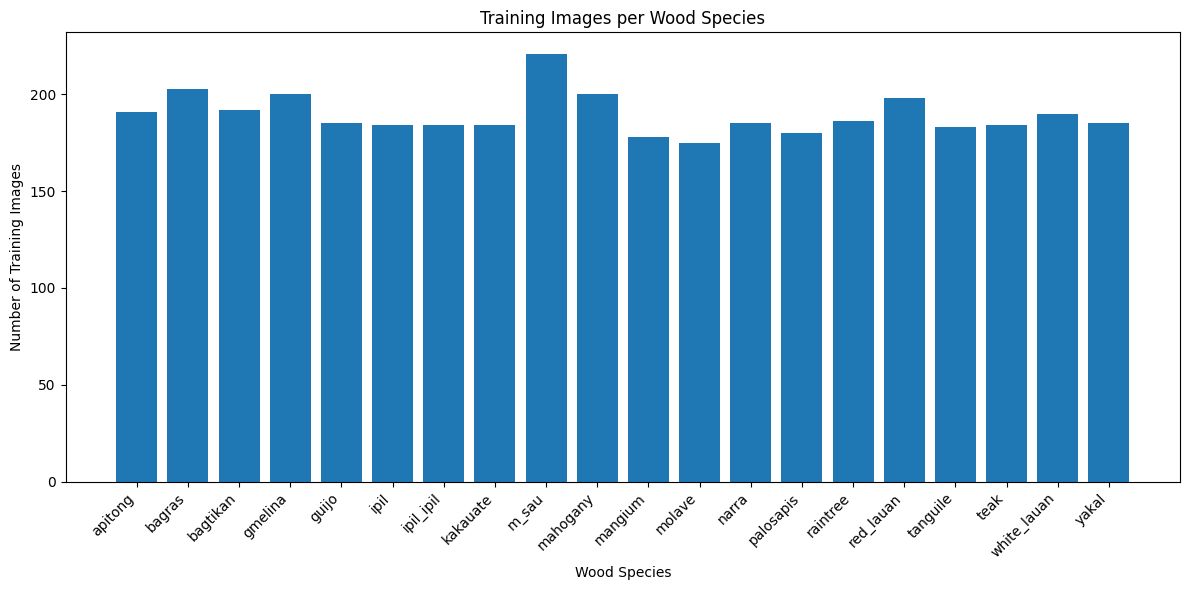

In [9]:
plt.figure(figsize=(12, 6))

counts = [class_counts[i] for i in range(len(class_names))]

plt.bar(class_names, counts)
plt.xlabel("Wood Species")
plt.ylabel("Number of Training Images")
plt.title("Training Images per Wood Species")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 4. Transfer Learning with VGG16

VGG16 pretrained on ImageNet is used as the base convolutional neural network. The pretrained convolutional layers are initially frozen, and custom classification layers are added on top for the 20 wood species.

### Load Pretrained VGG16

In [10]:
num_classes = NUM_CLASSES

vgg = tf.keras.applications.VGG16(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

### Freeze VGG16

In [11]:
vgg.trainable = False

### VGG16 Model Summary

In [12]:
print("VGG16 MODEL SUMMARY:")
vgg.summary()

VGG16 MODEL SUMMARY:
Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 

### Custom Classification Layers

The original VGG16 classification head is removed using `include_top=False`. Custom layers are added to classify the images into the 20 wood species.

In [13]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()

batch_norm_layer = tf.keras.layers.BatchNormalization(
    momentum=0.9
)

dropout_layer = tf.keras.layers.Dropout(0.5)

dense_layer = tf.keras.layers.Dense(
    512,
    activation="relu"
)

prediction_layer = tf.keras.layers.Dense(
    num_classes,
    activation="softmax"
)

In [14]:
x = vgg(vgg.input, training=False)
x = global_average_layer(x)
x = dense_layer(x)
x = batch_norm_layer(x)
x = dropout_layer(x)
x = dense_layer(x)
x = dense_layer(x)

output = prediction_layer(x)

### Custom Model Summary

In [15]:
model = tf.keras.Model(
    inputs=vgg.input,
    outputs=output
)

In [16]:
print("CUSTOM MODEL SUMMARY")
model.summary()

CUSTOM MODEL SUMMARY
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 vgg16 (Functional)             (None, 7, 7, 512)    14714688    ['input_1[0][0]']                
                                                                                                  
 global_average_pooling2d (Glob  (None, 512)         0           ['vgg16[0][0]']                  
 alAveragePooling2D)                                                                              
                                                                         

## 5. Phase 1 — Transfer Learning

During the first training phase, the pretrained VGG16 convolutional layers remain frozen. Only the custom classification layers are trained using the wood species dataset.

### Compile Model

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=0.0001,
        momentum=0.9
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

### Train Model

In [18]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30
)

Epoch 1/30
119/119 [==============================] - 64s 425ms/step - loss: 3.1337 - accuracy: 0.0692 - val_loss: 2.7795 - val_accuracy: 0.1638
Epoch 2/30
119/119 [==============================] - 44s 353ms/step - loss: 2.7051 - accuracy: 0.1798 - val_loss: 2.4487 - val_accuracy: 0.3252
Epoch 3/30
119/119 [==============================] - 45s 360ms/step - loss: 2.4466 - accuracy: 0.2722 - val_loss: 2.1831 - val_accuracy: 0.4130
Epoch 4/30
119/119 [==============================] - 44s 356ms/step - loss: 2.2093 - accuracy: 0.3812 - val_loss: 1.9954 - val_accuracy: 0.4765
Epoch 5/30
119/119 [==============================] - 44s 356ms/step - loss: 2.0431 - accuracy: 0.4290 - val_loss: 1.8665 - val_accuracy: 0.5078
Epoch 6/30
119/119 [==============================] - 45s 359ms/step - loss: 1.9112 - accuracy: 0.4527 - val_loss: 1.7372 - val_accuracy: 0.5353
Epoch 7/30
119/119 [==============================] - 45s 364ms/step - loss: 1.8086 - accuracy: 0.5005 - val_loss: 1.6280 - val_ac

### Training History & Visualization

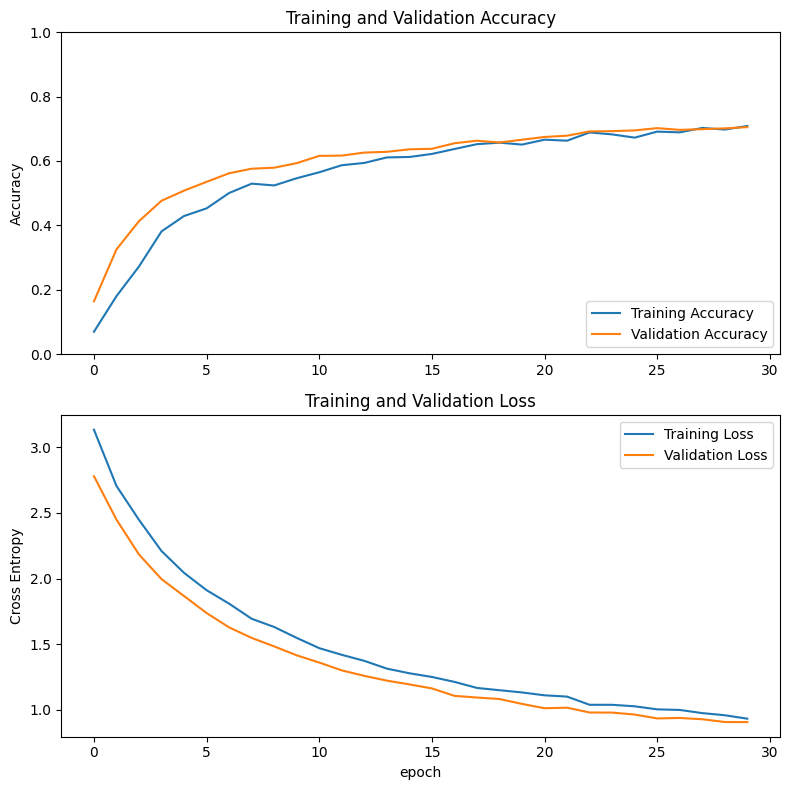

In [19]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.figure(figsize=(8, 8))

plt.subplot(2, 1, 1)
plt.plot(acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.ylabel("Accuracy")
plt.ylim([0, 1])
plt.title("Training and Validation Accuracy")

plt.subplot(2, 1, 2)
plt.plot(loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.ylabel("Cross Entropy")
plt.title("Training and Validation Loss")

plt.xlabel("epoch")
plt.tight_layout()
plt.show()

### Test Evaluation

In [20]:
loss, accuracy = model.evaluate(
    test_ds,
    verbose=0
)

print("Test loss:", loss)
print("Test accuracy:", accuracy)

Test loss: 0.9064427018165588
Test accuracy: 0.7027243375778198


## 6. Phase 2 — Fine-Tuning

After the initial transfer-learning phase, selected VGG16 layers are unfrozen and the model is fine-tuned using the wood species dataset.

### Unfreeze Selected VGG16 Layers

In [21]:
vgg.trainable = True

for layer in vgg.layers[:16]:
    layer.trainable = False

### Compile Model

In [22]:
model.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001,
        decay=0.0005
    ),
    metrics=["accuracy"]
)

In [23]:
print("CUSTOM MODEL SUMMARY: PHASE 2")
model.summary()

CUSTOM MODEL SUMMARY: PHASE 2
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 vgg16 (Functional)             (None, 7, 7, 512)    14714688    ['input_1[0][0]']                
                                                                                                  
 global_average_pooling2d (Glob  (None, 512)         0           ['vgg16[0][0]']                  
 alAveragePooling2D)                                                                              
                                                                

### Early Stopping

In [24]:
es = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    min_delta=0.01,
    patience=10,
    restore_best_weights=True
)

cb_list = [es]

### Fine-tune Model

In [25]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=cb_list
)

Epoch 1/100
119/119 [==============================] - 47s 357ms/step - loss: 0.8986 - accuracy: 0.7128 - val_loss: 0.7214 - val_accuracy: 0.7719
Epoch 2/100
119/119 [==============================] - 43s 347ms/step - loss: 0.7136 - accuracy: 0.7735 - val_loss: 0.7284 - val_accuracy: 0.7516
Epoch 3/100
119/119 [==============================] - 43s 347ms/step - loss: 0.5370 - accuracy: 0.8281 - val_loss: 0.4638 - val_accuracy: 0.8472
Epoch 4/100
119/119 [==============================] - 43s 346ms/step - loss: 0.4102 - accuracy: 0.8691 - val_loss: 0.4404 - val_accuracy: 0.8519
Epoch 5/100
119/119 [==============================] - 43s 346ms/step - loss: 0.3416 - accuracy: 0.8881 - val_loss: 0.4796 - val_accuracy: 0.8276
Epoch 6/100
119/119 [==============================] - 43s 349ms/step - loss: 0.3030 - accuracy: 0.9050 - val_loss: 0.4178 - val_accuracy: 0.8534
Epoch 7/100
119/119 [==============================] - 43s 349ms/step - loss: 0.2574 - accuracy: 0.9174 - val_loss: 0.3897 -

### Training History & Visualization

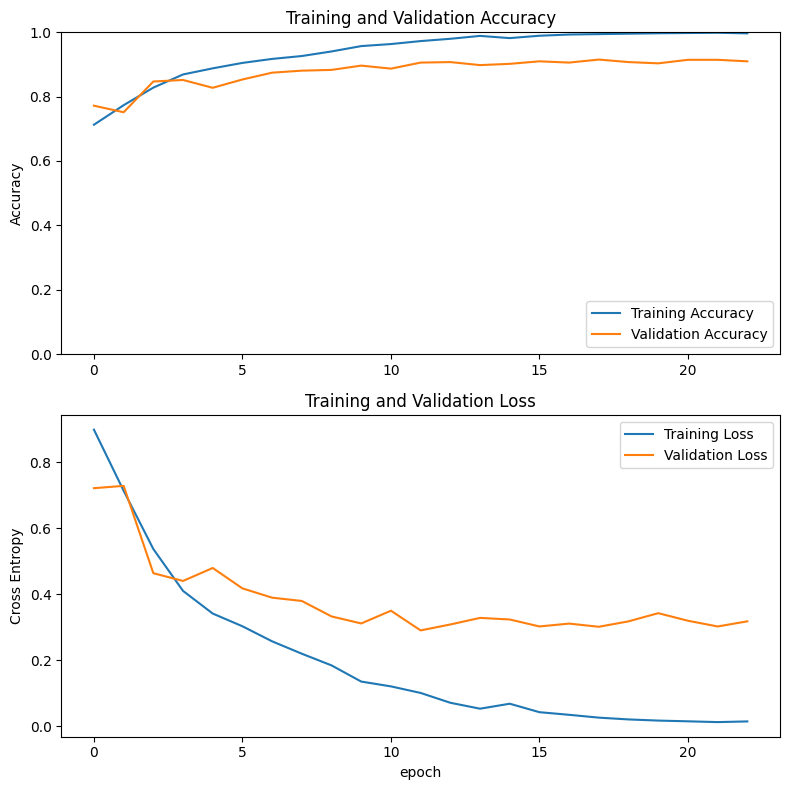

In [26]:
acc = history_fine.history["accuracy"]
val_acc = history_fine.history["val_accuracy"]

loss = history_fine.history["loss"]
val_loss = history_fine.history["val_loss"]

plt.figure(figsize=(8, 8))

plt.subplot(2, 1, 1)
plt.plot(acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.ylabel("Accuracy")
plt.ylim([0, 1])
plt.title("Training and Validation Accuracy")

plt.subplot(2, 1, 2)
plt.plot(loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.ylabel("Cross Entropy")
plt.title("Training and Validation Loss")

plt.xlabel("epoch")
plt.tight_layout()
plt.show()

### Test Evaluation

In [27]:
loss, accuracy = model.evaluate(
    test_ds,
    verbose=0
)

print("Test loss:", loss)
print("Test accuracy:", accuracy)

Test loss: 0.34562948346138
Test accuracy: 0.8926281929016113


## 7. Confusion Matrix

### Generate Predictions

In [28]:
predictions = np.array([])
labels = np.array([])

for x, y in test_ds:
    predictions = np.concatenate(
        [predictions, np.argmax(model.predict(x), axis=1)]
    )
    labels = np.concatenate(
        [labels, np.argmax(y.numpy(), axis=-1)]
    )

1/1 [==============================] - 0s 49ms/step


### Create Confusion Matrix

In [ ]:
conmatrix = confusion_matrix(
    labels,
    predictions
)

### Visualize Confusion Matrix

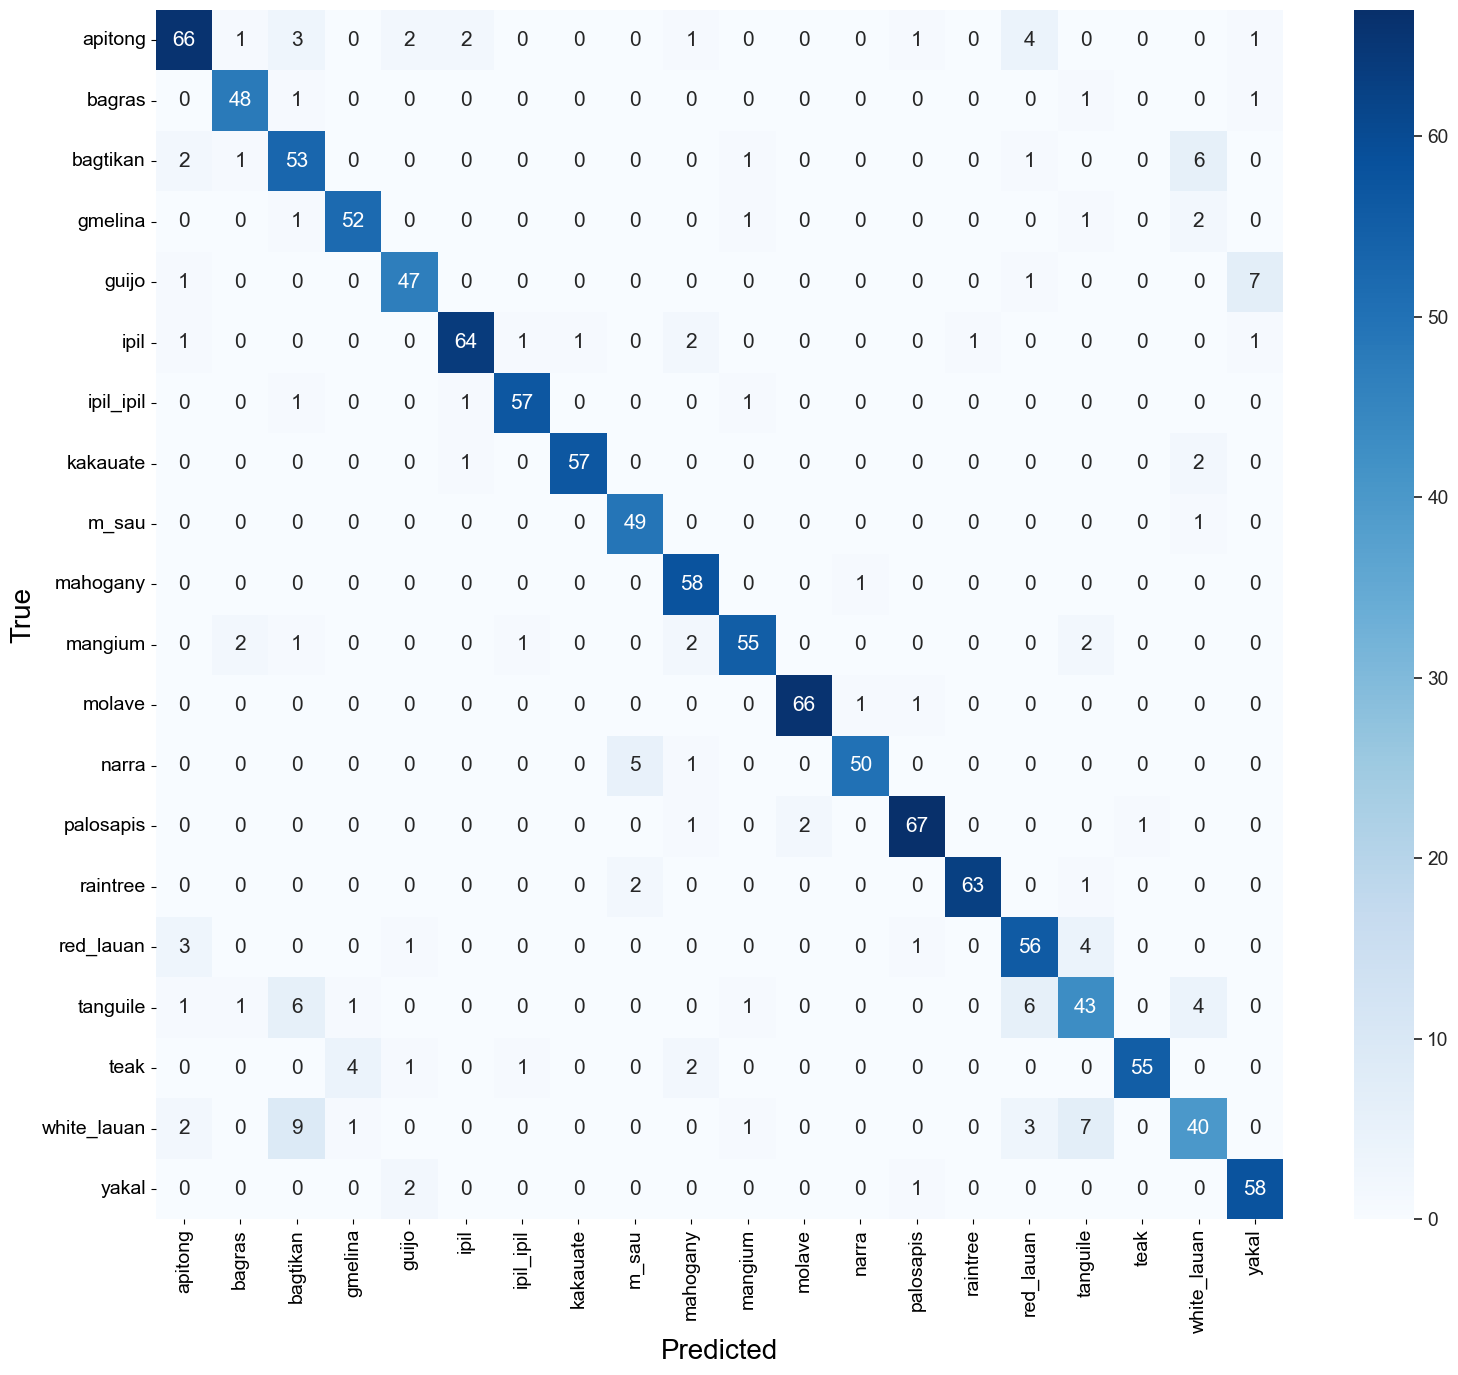

In [30]:
fig = plt.figure(figsize=(16, 14))
ax = plt.subplot()

sns.set(font_scale=1.25)

sns.heatmap(
    conmatrix,
    annot=True,
    ax=ax,
    fmt="g",
    cmap="Blues"
)

ax.set_xlabel("Predicted", fontsize=20)
ax.xaxis.set_label_position("bottom")

plt.xticks(
    ticks=np.arange(0.5, 20.5, 1),
    labels=class_names,
    fontsize=14,
    rotation=90
)

ax.xaxis.tick_bottom()

ax.set_ylabel("True", fontsize=20)

plt.yticks(
    ticks=np.arange(0.5, 20.5, 1),
    labels=class_names,
    fontsize=14,
    rotation=0
)

plt.tight_layout()
plt.show()

## 8. Results

The final model achieved an F1 score of 88.43% on the test dataset. Additionally, it achieved a Precision score of 88.67% and a Recall score of 88.46%.

In [31]:
precision = precision_score(labels, predictions, average='weighted')
recall = recall_score(labels, predictions, average='weighted')
f1 = f1_score(labels, predictions, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Precision: 0.8867
Recall:    0.8846
F1 Score:  0.8843


### Loading the Model

To load the model, use:

In [ ]:
#model = tf.keras.models.load_model("models/wood_classifier_final.keras")

In [ ]:
#model.load_weights("models/wood_classifier_final.weights.h5")